In [39]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import jcamp
from scipy.optimize import curve_fit 

In [40]:
#define some constants
t0 = 0 #s
tf = 3600 #s
k = 5.15E-4 #s-1
C0 = [1] #mol/L

#define the reaction rate 
def func(t, y) :
    return -k*y

t_eval = np.linspace(t0, tf, tf+1)

#solve the differential equation
sol = integrate.solve_ivp(func, (t0,tf),C0,t_eval=t_eval)

#concentrations across time
C_EtCl = sol.y[0]
C_MeCOH = 1 - C_EtCl

[0.99989928] [[3.26682509e-11]]


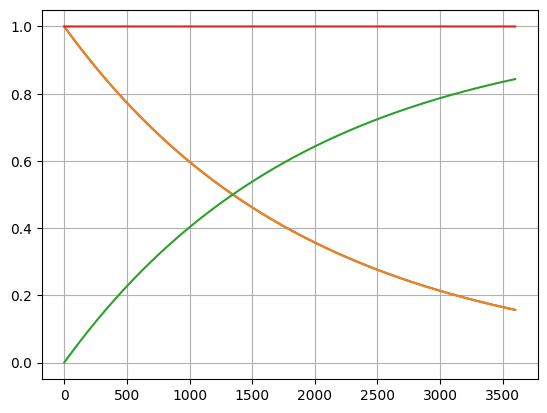

In [41]:
#exponential fit shanningans (actually not sure abt what i wrote)
x = np.linspace(t0, tf, len(C_EtCl))
y = C_EtCl

def expo(x, a) :
    return a*np.exp(-k*x)

popt, pcov = curve_fit(expo, x, y)


Cfit_EtCl = expo(t_eval, popt[0])
Cfit_MeCOH = 1 - Cfit_EtCl

print(popt, pcov)

fig = plt.Figure()
plt.grid(True)
plt.plot(x,y)
plt.plot(t_eval,Cfit_EtCl)
plt.plot(t_eval,Cfit_MeCOH)
plt.plot(t_eval,Cfit_EtCl + Cfit_MeCOH)
plt.show()

ValueError: operands could not be broadcast together with shapes (3826,) (2778,) 

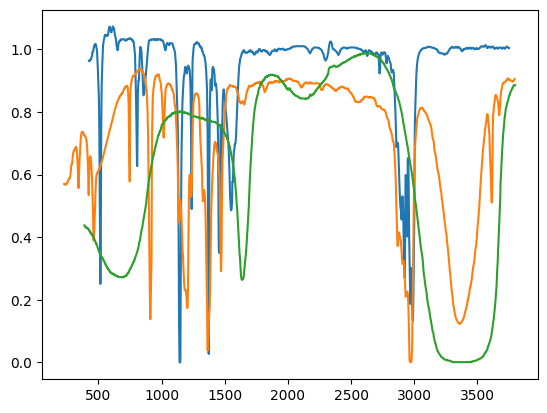

In [ ]:
filename_CBr ="IR_CBr_507-19-7-IR.jdx" # add the name of your .jdx file
filename_COH ="IR_COH_75-65-0-IR.jdx" # add the name of your .jdx file
filename_H2O ="IR_H2O_7732-18-5-IR.jdx" # add the name of your .jdx file

with open(filename_CBr, "r") as file:

    my_data_dict1 = jcamp.jcamp_read(file) # my_data_dict is a dictionary

with open(filename_COH, "r") as file:

    my_data_dict2 = jcamp.jcamp_read(file) # my_data_dict is a dictionary

with open(filename_H2O, "r") as file:

    my_data_dict3 = jcamp.jcamp_read(file) # my_data_dict is a dictionary

plt.plot(my_data_dict1['x'], my_data_dict1['y'])
plt.plot(my_data_dict2['x'], my_data_dict2['y'])
plt.plot(my_data_dict3['x'], my_data_dict3['y'])

plt.title('My spectrum')
